
# Illustrative process-energy comparison for two polyester thermoset routes

This notebook restructures the original calculation into a transparent, unit-consistent model and adds Monte Carlo uncertainty bounds.

## Purpose

The calculation asks whether the prolonged thermal cure used for the branched glycerol–citrate–itaconate polyester is likely to impose an energy penalty relative to a conventional unsaturated polyester resin (UPR) route.

It is **not** a life-cycle assessment and does not establish a definitive industrial energy comparison. It estimates externally supplied process heat under stated laboratory-scale assumptions.

## Main corrections relative to the original notebook

- Heat-transfer **power** in watts is no longer added directly as though it were energy in joules.
- The second-by-second thermostat loops have been replaced by explicit process-energy terms.
- Positive and negative temperature changes are not hidden using `abs()`.
- The conventional temperature schedule is represented as named stages, avoiding mismatched time and temperature arrays.
- Both routes are placed on a common basis of **1 kg of final cured resin**.
- The branched prepolymer-preparation step is included so that process boundaries are more comparable.
- Results are reported as kWh per batch and kWh per kg of final cured resin.
- Uncertain inputs are sampled using triangular distributions, and the output is reported using percentile intervals rather than a single over-precise number.

## Energy terms

For each route,

\[
E_{\mathrm{total}}
=
E_{\mathrm{warm-up}}
+
E_{\mathrm{equipment\ hold}}
+
E_{\mathrm{evaporation}}
+
E_{\mathrm{auxiliary}}.
\]

The equipment-hold term represents the power required to keep an empty oven or reactor at temperature. Evaporation is added separately. If measured **loaded** wall-plug power is later used, take care not to count evaporation twice.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Mapping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 20260802
N_MONTE_CARLO = 20_000
AMBIENT_C = 20.0
LATENT_HEAT_WATER_KJ_PER_KG = 2257.0

rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.precision", 3)



## Core calculation functions

The model treats the final cured-resin mass as the reporting basis. Material heat capacity, equipment thermal mass, heating efficiency, hold power, evaporation and auxiliary equipment are accounted for separately.

A triangular distribution is used when only a plausible low value, most likely value and high value are available. These ranges are **illustrative placeholders** until replaced with measurements or traceable literature values.


In [2]:

@dataclass(frozen=True)
class TriangularRange:
    low: float
    mode: float
    high: float
    unit: str = ""
    factual_status: str = "Illustrative placeholder"

    def validate(self) -> None:
        if not (self.low <= self.mode <= self.high):
            raise ValueError(
                f"Triangular range must satisfy low <= mode <= high: {self}"
            )

    def sample(self, generator: np.random.Generator, size: int) -> np.ndarray:
        self.validate()
        return generator.triangular(self.low, self.mode, self.high, size)


def warmup_energy_kwh(
    material_mass_kg: np.ndarray,
    material_cp_kj_per_kg_k: np.ndarray,
    equipment_heat_capacity_kj_per_k: np.ndarray,
    start_temp_c: float | np.ndarray,
    end_temp_c: float | np.ndarray,
    heater_efficiency: np.ndarray,
) -> np.ndarray:
    """Externally supplied energy to raise material and equipment temperature."""
    delta_t_k = np.asarray(end_temp_c) - np.asarray(start_temp_c)
    if np.any(delta_t_k < 0):
        raise ValueError("Warm-up temperature change cannot be negative.")
    if np.any(material_mass_kg <= 0):
        raise ValueError("Material mass must be positive.")
    if np.any(material_cp_kj_per_kg_k <= 0):
        raise ValueError("Specific heat capacity must be positive.")
    if np.any(equipment_heat_capacity_kj_per_k < 0):
        raise ValueError("Equipment heat capacity cannot be negative.")
    if np.any((heater_efficiency <= 0) | (heater_efficiency > 1)):
        raise ValueError("Heater efficiency must lie in (0, 1].")

    thermal_capacity_kj_per_k = (
        material_mass_kg * material_cp_kj_per_kg_k
        + equipment_heat_capacity_kj_per_k
    )
    return thermal_capacity_kj_per_k * delta_t_k / heater_efficiency / 3600.0


def evaporation_energy_kwh(
    water_mass_kg: np.ndarray,
    latent_heat_kj_per_kg: float,
    heater_efficiency: np.ndarray,
) -> np.ndarray:
    """Externally supplied latent heat for water removal."""
    if np.any(water_mass_kg < 0):
        raise ValueError("Water mass cannot be negative.")
    if latent_heat_kj_per_kg <= 0:
        raise ValueError("Latent heat must be positive.")
    if np.any((heater_efficiency <= 0) | (heater_efficiency > 1)):
        raise ValueError("Heater efficiency must lie in (0, 1].")
    return water_mass_kg * latent_heat_kj_per_kg / heater_efficiency / 3600.0


def hold_energy_kwh(
    standby_power_kw: np.ndarray,
    duration_h: np.ndarray,
) -> np.ndarray:
    """Equipment heat-loss energy over a hold period."""
    if np.any(standby_power_kw < 0):
        raise ValueError("Standby power cannot be negative.")
    if np.any(duration_h < 0):
        raise ValueError("Duration cannot be negative.")
    return standby_power_kw * duration_h


def auxiliary_energy_kwh(
    auxiliary_power_kw: np.ndarray,
    duration_h: np.ndarray,
) -> np.ndarray:
    if np.any(auxiliary_power_kw < 0):
        raise ValueError("Auxiliary power cannot be negative.")
    if np.any(duration_h < 0):
        raise ValueError("Duration cannot be negative.")
    return auxiliary_power_kw * duration_h



## Process boundaries and assumptions

### Branched polyester route

The model includes:

1. prepolymer preparation up to approximately 140 °C;
2. transfer to the mould and a fresh warm-up from room temperature to 90 °C;
3. a 7–14 day thermal cure;
4. evaporation of condensation water;
5. optional stirring or other auxiliary power during prepolymer preparation.

### Conventional UPR route

The model includes:

1. melt polycondensation of the unsaturated polyester using the staged 150–210 °C, 12 h schedule from the original notebook;
2. removal of condensation water;
3. auxiliary power during cooking;
4. no externally supplied heat for the subsequent room-temperature crosslinking step.

The fraction of final UPR that is pre-manufactured unsaturated polyester is uncertain because the original notebook states both 60% polyester and a formulation containing 60% styrene. The Monte Carlo model therefore samples a broad 0.40–0.60 range and flags this for factual checking.


In [3]:

# All ranges below are deliberately visible and editable.
# They are not presented as verified material or equipment properties.

branched_ranges: Mapping[str, TriangularRange] = {
    "cure_duration_days": TriangularRange(
        4.0, 5.0, 6.0, "days",
        "Check against the actual stopping-time records for all formulations."
    ),
    "cure_oven_standby_power_kw": TriangularRange(
        0.10, 0.35, 0.80, "kW",
        "Measure empty-oven wall-plug energy at 90 °C."
    ),
    "prepolymer_duration_h": TriangularRange(
        0.08, 0.16, 0.25, "h",
        "Check laboratory records for the actual dissolution/prepolymer time."
    ),
    "prepolymer_standby_power_kw": TriangularRange(
        0.10, 0.30, 0.80, "kW",
        "Measure hotplate/reactor wall-plug power at the relevant loading."
    ),
    "material_cp_kj_per_kg_k": TriangularRange(
        1.2, 1.8, 2.5, "kJ kg^-1 K^-1",
        "Replace with measured DSC heat capacity or justified literature values."
    ),
    "prepolymer_equipment_heat_capacity_kj_per_k": TriangularRange(
        2.0, 8.0, 20.0, "kJ K^-1",
        "Estimate from vessel/hotplate masses and material heat capacities."
    ),
    "cure_equipment_heat_capacity_kj_per_k": TriangularRange(
        10.0, 30.0, 80.0, "kJ K^-1",
        "Estimate from oven shelves, moulds and internal thermal mass."
    ),
    "heater_efficiency": TriangularRange(
        0.55, 0.75, 0.90, "fraction",
        "Replace with measured wall-plug input versus useful heat if available."
    ),
    "water_loss_fraction_of_initial": TriangularRange(
        0.15, 0.20, 0.25, "fraction",
        "Replace with the measured mass-loss distribution for the chosen batch."
    ),
    "prepolymer_auxiliary_power_kw": TriangularRange(
        0.00, 0.03, 0.10, "kW",
        "Check stirrer and ventilation power; avoid adding facility-wide loads."
    ),
}

upr_ranges: Mapping[str, TriangularRange] = {
    "polyester_fraction_of_final_resin": TriangularRange(
        0.50, 0.60, 0.70, "fraction",
        "Resolve the contradiction between '60% polyester' and '60% styrene'."
    ),
    "schedule_time_multiplier": TriangularRange(
        0.83, 1.00, 1.17, "fraction",
        "Verify the actual industrial or laboratory cook duration."
    ),
    "reactor_standby_power_at_210c_kw": TriangularRange(
        0.10, 0.40, 1.20, "kW",
        "Replace with measured or sourced reactor heat-loss power."
    ),
    "material_cp_kj_per_kg_k": TriangularRange(
        1.2, 1.8, 2.5, "kJ kg^-1 K^-1",
        "Replace with composition-specific measured or literature values."
    ),
    "reactor_equipment_heat_capacity_kj_per_k": TriangularRange(
        3.0, 15.0, 50.0, "kJ K^-1",
        "Estimate from reactor, agitator, condenser and contents."
    ),
    "heater_efficiency": TriangularRange(
        0.55, 0.75, 0.90, "fraction",
        "Replace with measured wall-plug input versus useful heat."
    ),
    "water_loss_fraction_of_polyester_feed": TriangularRange(
        0.10, 0.18, 0.25, "fraction",
        "Calculate from the actual stoichiometry or production mass balance."
    ),
    "auxiliary_power_kw": TriangularRange(
        0.00, 0.08, 0.30, "kW",
        "Check agitator, condenser, inert-gas and vacuum requirements."
    ),
}

assumption_table = pd.DataFrame(
    [
        {
            "route": route,
            "parameter": name,
            "low": spec.low,
            "mode": spec.mode,
            "high": spec.high,
            "unit": spec.unit,
            "factual check": spec.factual_status,
        }
        for route, ranges in (
            ("Branched polyester", branched_ranges),
            ("Conventional UPR", upr_ranges),
        )
        for name, spec in ranges.items()
    ]
)

assumption_table


,route,parameter,low,mode,high,unit,factual check
0,Branched polyester,cure_duration_days,4.00,5.00,6.00,days,Check against the actual stopping-time records...
1,Branched polyester,cure_oven_standby_power_kw,0.10,0.35,0.80,kW,Measure empty-oven wall-plug energy at 90 °C.
2,Branched polyester,prepolymer_duration_h,0.08,0.16,0.25,h,Check laboratory records for the actual dissol...
3,Branched polyester,prepolymer_standby_power_kw,0.10,0.30,0.80,kW,Measure hotplate/reactor wall-plug power at th...
4,Branched polyester,material_cp_kj_per_kg_k,1.20,1.80,2.50,kJ kg^-1 K^-1,Replace with measured DSC heat capacity or jus...
5,Branched polyester,prepolymer_equipment_heat_capacity_kj_per_k,2.00,8.00,20.00,kJ K^-1,Estimate from vessel/hotplate masses and mater...
6,Branched polyester,cure_equipment_heat_capacity_kj_per_k,10.00,30.00,80.00,kJ K^-1,"Estimate from oven shelves, moulds and interna..."
7,Branched polyester,heater_efficiency,0.55,0.75,0.90,fraction,Replace with measured wall-plug input versus u...
8,Branched polyester,water_loss_fraction_of_initial,0.15,0.20,0.25,fraction,Replace with the measured mass-loss distributi...
9,Branched polyester,prepolymer_auxiliary_power_kw,0.00,0.03,0.10,kW,Check stirrer and ventilation power; avoid add...



## Conventional UPR cooking schedule

The original notebook used a 12 h schedule that stepped from 150 °C to 210 °C. It is represented explicitly here. Each stage duration is multiplied by the sampled schedule-time factor.

The reactor standby power at each temperature is scaled in proportion to the temperature difference above ambient. This is only an approximation; measured power at each setpoint would be preferable.


In [4]:

upr_schedule = pd.DataFrame(
    {
        "stage": [
            "150 °C stage",
            "160 °C stage",
            "170 °C stage",
            "180 °C stage",
            "190 °C stage",
            "200 °C stage",
            "210 °C ramp/hold",
            "210 °C final hold",
        ],
        "start_temp_c": [20.0, 150.0, 160.0, 170.0, 180.0, 190.0, 200.0, 210.0],
        "end_temp_c":   [150.0, 160.0, 170.0, 180.0, 190.0, 200.0, 210.0, 210.0],
        "base_duration_h": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0],
    }
)

assert np.isclose(upr_schedule["base_duration_h"].sum(), 12.0)
upr_schedule


,stage,start_temp_c,end_temp_c,base_duration_h
0,150 °C stage,20.0,150.0,1.0
1,160 °C stage,150.0,160.0,1.0
2,170 °C stage,160.0,170.0,1.0
3,180 °C stage,170.0,180.0,1.0
4,190 °C stage,180.0,190.0,1.0
5,200 °C stage,190.0,200.0,1.0
6,210 °C ramp/hold,200.0,210.0,1.0
7,210 °C final hold,210.0,210.0,5.0


## Route models

In [5]:

def sample_ranges(
    ranges: Mapping[str, TriangularRange],
    generator: np.random.Generator,
    size: int,
) -> dict[str, np.ndarray]:
    return {
        name: specification.sample(generator, size)
        for name, specification in ranges.items()
    }


def branched_route_energy(
    samples: Mapping[str, np.ndarray],
    final_resin_mass_kg: float = 1.0,
) -> pd.DataFrame:
    if final_resin_mass_kg <= 0:
        raise ValueError("Final resin mass must be positive.")

    n = len(samples["cure_duration_days"])
    final_mass = np.full(n, final_resin_mass_kg)
    water_fraction = samples["water_loss_fraction_of_initial"]

    # If water fraction is defined relative to initial mass:
    # final = initial * (1 - fraction)
    initial_mass = final_mass / (1.0 - water_fraction)
    water_mass = initial_mass - final_mass
    average_cure_mass = 0.5 * (initial_mass + final_mass)

    prepolymer_warmup = warmup_energy_kwh(
        material_mass_kg=initial_mass,
        material_cp_kj_per_kg_k=samples["material_cp_kj_per_kg_k"],
        equipment_heat_capacity_kj_per_k=samples[
            "prepolymer_equipment_heat_capacity_kj_per_k"
        ],
        start_temp_c=AMBIENT_C,
        end_temp_c=140.0,
        heater_efficiency=samples["heater_efficiency"],
    )

    prepolymer_hold = hold_energy_kwh(
        samples["prepolymer_standby_power_kw"],
        samples["prepolymer_duration_h"],
    )

    prepolymer_aux = auxiliary_energy_kwh(
        samples["prepolymer_auxiliary_power_kw"],
        samples["prepolymer_duration_h"],
    )

    # Assumes the material and mould return approximately to room temperature
    # before the prolonged oven cure. Edit if the actual workflow differs.
    cure_warmup = warmup_energy_kwh(
        material_mass_kg=average_cure_mass,
        material_cp_kj_per_kg_k=samples["material_cp_kj_per_kg_k"],
        equipment_heat_capacity_kj_per_k=samples[
            "cure_equipment_heat_capacity_kj_per_k"
        ],
        start_temp_c=50.0,
        end_temp_c=90.0,
        heater_efficiency=samples["heater_efficiency"],
    )

    cure_duration_h = samples["cure_duration_days"] * 24.0
    cure_hold = hold_energy_kwh(
        samples["cure_oven_standby_power_kw"],
        cure_duration_h,
    )

    evaporation = evaporation_energy_kwh(
        water_mass,
        LATENT_HEAT_WATER_KJ_PER_KG,
        samples["heater_efficiency"],
    )

    total = (
        prepolymer_warmup
        + prepolymer_hold
        + prepolymer_aux
        + cure_warmup
        + cure_hold
        + evaporation
    )

    return pd.DataFrame(
        {
            "prepolymer_warmup_kwh": prepolymer_warmup,
            "prepolymer_hold_kwh": prepolymer_hold,
            "prepolymer_aux_kwh": prepolymer_aux,
            "cure_warmup_kwh": cure_warmup,
            "cure_hold_kwh": cure_hold,
            "evaporation_kwh": evaporation,
            "total_kwh_per_batch": total,
            "specific_kwh_per_kg_final": total / final_mass,
        }
    )


def upr_route_energy(
    samples: Mapping[str, np.ndarray],
    final_resin_mass_kg: float = 1.0,
) -> pd.DataFrame:
    if final_resin_mass_kg <= 0:
        raise ValueError("Final resin mass must be positive.")

    n = len(samples["polyester_fraction_of_final_resin"])
    final_mass = np.full(n, final_resin_mass_kg)

    final_polyester_mass = (
        final_mass * samples["polyester_fraction_of_final_resin"]
    )
    water_fraction = samples["water_loss_fraction_of_polyester_feed"]
    polyester_feed_mass = final_polyester_mass / (1.0 - water_fraction)
    water_mass = polyester_feed_mass - final_polyester_mass

    warmup_total = np.zeros(n)
    hold_total = np.zeros(n)

    for _, stage in upr_schedule.iterrows():
        warmup_total += warmup_energy_kwh(
            material_mass_kg=polyester_feed_mass,
            material_cp_kj_per_kg_k=samples["material_cp_kj_per_kg_k"],
            equipment_heat_capacity_kj_per_k=samples[
                "reactor_equipment_heat_capacity_kj_per_k"
            ],
            start_temp_c=stage["start_temp_c"],
            end_temp_c=stage["end_temp_c"],
            heater_efficiency=samples["heater_efficiency"],
        )

        temperature_scaling = (
            (stage["end_temp_c"] - AMBIENT_C)
            / (210.0 - AMBIENT_C)
        )
        stage_hold_power = (
            samples["reactor_standby_power_at_210c_kw"]
            * temperature_scaling
        )
        stage_duration = (
            stage["base_duration_h"]
            * samples["schedule_time_multiplier"]
        )
        hold_total += hold_energy_kwh(stage_hold_power, stage_duration)

    total_duration_h = (
        upr_schedule["base_duration_h"].sum()
        * samples["schedule_time_multiplier"]
    )
    auxiliary = auxiliary_energy_kwh(
        samples["auxiliary_power_kw"],
        total_duration_h,
    )
    evaporation = evaporation_energy_kwh(
        water_mass,
        LATENT_HEAT_WATER_KJ_PER_KG,
        samples["heater_efficiency"],
    )

    total = warmup_total + hold_total + auxiliary + evaporation

    return pd.DataFrame(
        {
            "cook_warmup_kwh": warmup_total,
            "cook_hold_kwh": hold_total,
            "auxiliary_kwh": auxiliary,
            "evaporation_kwh": evaporation,
            "total_kwh_per_batch": total,
            "specific_kwh_per_kg_final": total / final_mass,
        }
    )



## Deterministic midpoint check

This cell uses each triangular distribution's most-likely value. It is a code and unit sanity check, not the principal result.


In [6]:

def modal_samples(
    ranges: Mapping[str, TriangularRange],
    size: int = 1,
) -> dict[str, np.ndarray]:
    return {
        name: np.full(size, specification.mode, dtype=float)
        for name, specification in ranges.items()
    }


branched_modal = branched_route_energy(modal_samples(branched_ranges))
upr_modal = upr_route_energy(modal_samples(upr_ranges))

modal_summary = pd.DataFrame(
    {
        "route": ["Branched polyester", "Conventional UPR"],
        "kWh per kg final resin": [
            branched_modal.loc[0, "specific_kwh_per_kg_final"],
            upr_modal.loc[0, "specific_kwh_per_kg_final"],
        ],
    }
)
modal_summary


,route,kWh per kg final resin
0,Branched polyester,43.192
1,Conventional UPR,6.576


In [7]:

modal_ratio = (
    upr_modal.loc[0, "specific_kwh_per_kg_final"]
    / branched_modal.loc[0, "specific_kwh_per_kg_final"]
)
modal_fold = 1.0 / modal_ratio

print(
    "At the modal assumptions, conventional UPR uses "
    f"{100 * modal_ratio:.1f}% as much modelled process energy as the "
    "branched route."
)
print(
    "Equivalently, the branched route uses approximately "
    f"{modal_fold:.1f} times as much modelled process energy."
)


At the modal assumptions, conventional UPR uses 15.2% as much modelled process energy as the branched route.
Equivalently, the branched route uses approximately 6.6 times as much modelled process energy.



## Monte Carlo uncertainty propagation

The two routes are sampled independently because many uncertainties are route-specific. The calculation reports 5th, 50th and 95th percentiles. These are **model-input uncertainty bounds**, not experimentally validated confidence intervals.


In [8]:

branched_sampled_inputs = sample_ranges(
    branched_ranges, rng, N_MONTE_CARLO
)
upr_sampled_inputs = sample_ranges(
    upr_ranges, rng, N_MONTE_CARLO
)

branched_mc = branched_route_energy(branched_sampled_inputs)
upr_mc = upr_route_energy(upr_sampled_inputs)

comparison_mc = pd.DataFrame(
    {
        "branched_kwh_per_kg": branched_mc["specific_kwh_per_kg_final"],
        "upr_kwh_per_kg": upr_mc["specific_kwh_per_kg_final"],
    }
)
comparison_mc["upr_to_branched_ratio"] = (
    comparison_mc["upr_kwh_per_kg"]
    / comparison_mc["branched_kwh_per_kg"]
)
comparison_mc["branched_to_upr_fold"] = (
    comparison_mc["branched_kwh_per_kg"]
    / comparison_mc["upr_kwh_per_kg"]
)

assert np.isfinite(comparison_mc.to_numpy()).all()
assert (comparison_mc > 0).all().all()

comparison_mc.head()


,branched_kwh_per_kg,upr_kwh_per_kg,upr_to_branched_ratio,branched_to_upr_fold
0,43.980,11.901,0.271,3.696
1,38.579,9.292,0.241,4.152
2,63.299,6.837,0.108,9.259
3,23.987,13.168,0.549,1.822
4,86.945,8.428,0.097,10.316


In [9]:

def percentile_summary(series: pd.Series) -> pd.Series:
    quantiles = series.quantile([0.05, 0.50, 0.95])
    return pd.Series(
        {
            "5th percentile": quantiles.loc[0.05],
            "median": quantiles.loc[0.50],
            "95th percentile": quantiles.loc[0.95],
        }
    )


uncertainty_summary = pd.DataFrame(
    {
        "Branched polyester (kWh kg^-1)": percentile_summary(
            comparison_mc["branched_kwh_per_kg"]
        ),
        "Conventional UPR (kWh kg^-1)": percentile_summary(
            comparison_mc["upr_kwh_per_kg"]
        ),
        "UPR / branched energy ratio": percentile_summary(
            comparison_mc["upr_to_branched_ratio"]
        ),
        "Branched / UPR fold difference": percentile_summary(
            comparison_mc["branched_to_upr_fold"]
        ),
    }
).T

uncertainty_summary


,5th percentile,median,95th percentile
Branched polyester (kWh kg^-1),24.397,49.986,84.057
Conventional UPR (kWh kg^-1),5.367,9.240,14.566
UPR / branched energy ratio,0.087,0.186,0.431
Branched / UPR fold difference,2.319,5.369,11.447


In [10]:

prob_upr_lower = np.mean(
    comparison_mc["upr_kwh_per_kg"]
    < comparison_mc["branched_kwh_per_kg"]
)

ratio_q = comparison_mc["upr_to_branched_ratio"].quantile(
    [0.05, 0.50, 0.95]
)

print(
    f"In {100 * prob_upr_lower:.1f}% of the illustrative Monte Carlo draws, "
    "the conventional UPR route has the lower modelled process energy."
)
print(
    "The UPR/branched energy ratio has a median of "
    f"{ratio_q.loc[0.50]:.3f}, with a 5th–95th percentile range of "
    f"{ratio_q.loc[0.05]:.3f}–{ratio_q.loc[0.95]:.3f}."
)
print(
    "These values are conditional on the displayed input ranges and should "
    "not be interpreted as an industrial efficiency claim."
)


In 100.0% of the illustrative Monte Carlo draws, the conventional UPR route has the lower modelled process energy.
The UPR/branched energy ratio has a median of 0.186, with a 5th–95th percentile range of 0.087–0.431.
These values are conditional on the displayed input ranges and should not be interpreted as an industrial efficiency claim.


## Distribution plots

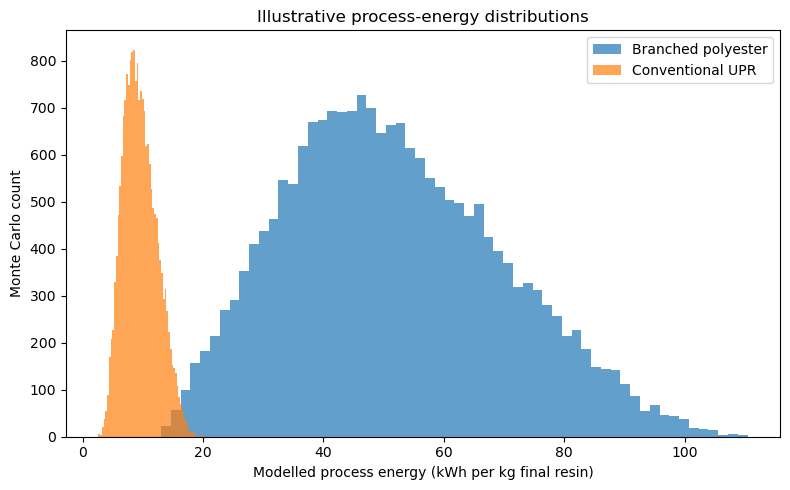

In [11]:

plt.figure(figsize=(8, 5))
plt.hist(
    comparison_mc["branched_kwh_per_kg"],
    bins=60,
    alpha=0.7,
    label="Branched polyester",
)
plt.hist(
    comparison_mc["upr_kwh_per_kg"],
    bins=60,
    alpha=0.7,
    label="Conventional UPR",
)
plt.xlabel("Modelled process energy (kWh per kg final resin)")
plt.ylabel("Monte Carlo count")
plt.title("Illustrative process-energy distributions")
plt.legend()
plt.tight_layout()
plt.show()


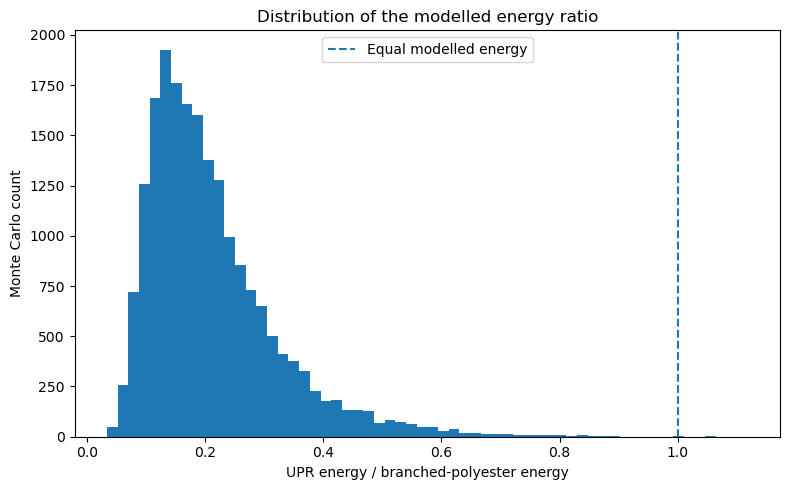

In [12]:

plt.figure(figsize=(8, 5))
plt.hist(
    comparison_mc["upr_to_branched_ratio"],
    bins=60,
)
plt.axvline(1.0, linestyle="--", label="Equal modelled energy")
plt.xlabel("UPR energy / branched-polyester energy")
plt.ylabel("Monte Carlo count")
plt.title("Distribution of the modelled energy ratio")
plt.legend()
plt.tight_layout()
plt.show()



## Approximate sensitivity analysis

Spearman rank correlations identify which uncertain inputs most strongly control each route's specific energy. They do not establish causation, but they show where measurement effort would most improve the calculation.


In [13]:

def rank_correlation_with_output(
    sampled_inputs: Mapping[str, np.ndarray],
    output: pd.Series,
) -> pd.Series:
    frame = pd.DataFrame(sampled_inputs)
    ranked_inputs = frame.rank(method="average")
    ranked_output = output.rank(method="average")
    correlations = ranked_inputs.apply(
        lambda column: column.corr(ranked_output)
    )
    return correlations.sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )


branched_sensitivity = rank_correlation_with_output(
    branched_sampled_inputs,
    branched_mc["specific_kwh_per_kg_final"],
)

upr_sensitivity = rank_correlation_with_output(
    upr_sampled_inputs,
    upr_mc["specific_kwh_per_kg_final"],
)

sensitivity_table = pd.concat(
    {
        "Branched polyester": branched_sensitivity,
        "Conventional UPR": upr_sensitivity,
    },
    axis=1,
)

sensitivity_table


,Branched polyester,Conventional UPR
cure_oven_standby_power_kw,0.975,NaN
cure_duration_days,0.218,NaN
heater_efficiency,-0.012,-5.634e-02
cure_equipment_heat_capacity_kj_per_k,0.009,NaN
prepolymer_equipment_heat_capacity_kj_per_k,0.007,NaN
prepolymer_auxiliary_power_kw,0.006,NaN
water_loss_fraction_of_initial,-0.006,NaN
material_cp_kj_per_kg_k,-0.005,7.058e-04
prepolymer_standby_power_kw,-0.003,NaN
prepolymer_duration_h,0.002,NaN


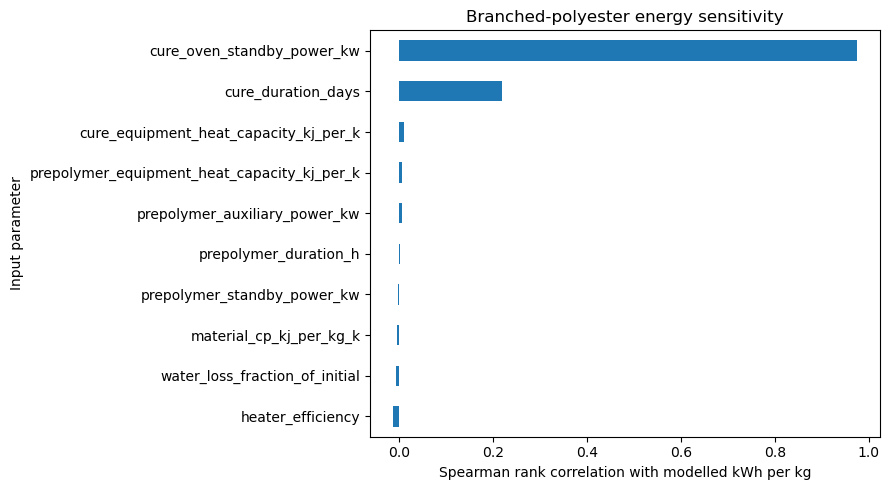

In [14]:

plt.figure(figsize=(9, 5))
branched_sensitivity.sort_values().plot(kind="barh")
plt.xlabel("Spearman rank correlation with modelled kWh per kg")
plt.ylabel("Input parameter")
plt.title("Branched-polyester energy sensitivity")
plt.tight_layout()
plt.show()


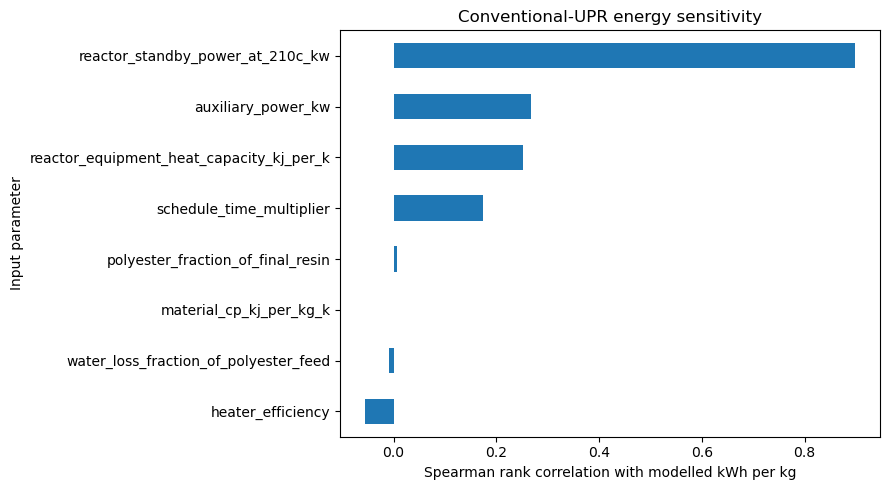

In [15]:

plt.figure(figsize=(9, 5))
upr_sensitivity.sort_values().plot(kind="barh")
plt.xlabel("Spearman rank correlation with modelled kWh per kg")
plt.ylabel("Input parameter")
plt.title("Conventional-UPR energy sensitivity")
plt.tight_layout()
plt.show()



## Component breakdown at modal assumptions

This helps distinguish energy associated with equipment hold time from material warm-up and water removal.


In [16]:

branched_components = (
    branched_modal.drop(
        columns=["total_kwh_per_batch", "specific_kwh_per_kg_final"]
    )
    .iloc[0]
    .rename("kWh per kg final resin")
    .to_frame()
)

upr_components = (
    upr_modal.drop(
        columns=["total_kwh_per_batch", "specific_kwh_per_kg_final"]
    )
    .iloc[0]
    .rename("kWh per kg final resin")
    .to_frame()
)

print("Branched polyester:")
display(branched_components)

print("Conventional UPR:")
display(upr_components)


Branched polyester:


,kWh per kg final resin
prepolymer_warmup_kwh,0.456
prepolymer_hold_kwh,0.048
prepolymer_aux_kwh,0.005
cure_warmup_kwh,0.474
cure_hold_kwh,42.000
evaporation_kwh,0.209


Conventional UPR:


,kWh per kg final resin
cook_warmup_kwh,1.148
cook_hold_kwh,4.358
auxiliary_kwh,0.960
evaporation_kwh,0.110



## Highest-priority factual checks

The calculation will become substantially more defensible if the following are measured or verified.

1. **Actual wall-plug energy of the cure oven at 90 °C.**  
   Measure kWh over at least 24 h with the oven empty and with a representative batch. Record oven make, model, internal volume and batch loading.

2. **Actual cure-time distribution.**  
   Use the recorded stopping times for the formulations rather than a generic 7–14 day interval. Cure time may itself correlate with composition and mass loss.

3. **Branched-prepolymer preparation duration and electricity use.**  
   Record hotplate or reactor wall-plug energy, vessel mass, batch mass and whether the material enters the cure oven hot or after cooling.

4. **Conventional UPR system boundary and formulation.**  
   Resolve the contradiction between 60% unsaturated polyester and 60% styrene. Select a clearly specified comparator resin and determine whether the quoted cooking schedule is laboratory, pilot or industrial.

5. **Conventional reactor energy.**  
   Replace the assumed standby-power range with measured data or a traceable source. Record stirring, condenser, vacuum and inert-gas requirements separately.

6. **Water mass balance.**  
   Calculate theoretical water generation from stoichiometry and compare it with actual mass loss. This improves both latent-heat and final-mass calculations.

7. **Material heat capacities and equipment thermal masses.**  
   Replace broad ranges with DSC measurements, literature values or component-by-component estimates.

8. **Exothermic heat of conventional crosslinking.**  
   The room-temperature cure is assigned zero external thermal energy, but the reaction exotherm and any temperature-control requirement are not modelled.

9. **Batch-size and utilisation effects.**  
   Report energy per batch and per kilogram. Laboratory ovens can appear extremely inefficient when lightly loaded; an industrial comparison requires an explicit loading factor.

10. **Upstream and end-of-life impacts.**  
    Feedstock production, solvent use, emissions, reactor construction and biodegradation are outside this process-heat model and would require a separate life-cycle assessment.

## Interpretation suitable for the manuscript

The calculation should be described as an **illustrative process-energy sensitivity analysis**, not as proof that one route is a precise percentage more energy-efficient.

A defensible conclusion is:

> Under the displayed laboratory-scale assumptions, the prolonged 90 °C cure is likely to impose a substantial energy and throughput penalty relative to the rapid final cure of a conventional unsaturated polyester resin. The magnitude of that penalty is controlled primarily by cure duration, oven standby power, batch loading and the system boundary applied to prepolymer manufacture. Direct wall-plug measurements are required before making a quantitative comparative claim.

The ratio should be stated as “UPR uses *x*% as much modelled process energy as the branched route” or as a fold difference. Avoid translating the ratio into “*x*% more energy efficient”, which is ambiguous and was misinterpreted in the original notebook.



## Reproducibility notes

- Random seed: `20260802`
- Monte Carlo draws: `20,000`
- Distribution family: triangular
- Reporting interval: 5th–95th percentiles
- All energy outputs: kWh
- Reporting basis: 1 kg of final cured resin

The model deliberately keeps assumptions in visible dictionaries near the top of the notebook so they can be replaced without changing the calculation functions.
